In [1]:
## perturbation experiments for dissecting hepg2 and k562 regulatory code 

In [2]:
import os, sys, pickle, numpy as np, pandas as pd

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

# Build EigenMap — HepG2 first so it plots on top
CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Build seq_idx -> raw npz index mapping (npz has all seq_valid rows,
# df used the additional keep filter dropping 3 rows)
raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]  # filtered_idx -> raw npz idx
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]  # correct mapping
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')
print(f'  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'  Focus TFs: {len(focus_tfs)}')
print(f'  Cell type order: {em.cell_types} (top row first)')

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences
  Conditions: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}
  Focus TFs: 151
  Cell type order: ['HepG2', 'K562'] (top row first)


In [3]:
import matplotlib.pyplot as plt
from fast_logo import fast_logo
FG_DIR = os.path.join(REPO, 'SEAM_target_spaces', 'results', 'foregrounds')
MOTIF_COLORS = plt.cm.tab10.colors

# Change here -> applies to both attribution and foreground plots
FIGSIZE_ROW = (15, 3)  # (width, height per cell-type row)

def show_fg(row, window_size=10, flank=5, pval_thresh=0.05, n_nearest=5,
            shape_feature=None, shape_layer=7, motif_annotations=True):
    sid, seq = int(row.seq_idx), row.sequence
    li = df.index.get_loc(row.name)
    ohe_enh = np.zeros((230, 4), dtype=np.float32)
    for i, b in enumerate(seq): ohe_enh[i, 'ACGT'.index(b)] = 1.0

    # Distinct EigenMap run on foreground signal -> re-annotate motifs
    em_fg = EigenMap(cell_types=list(CT))
    em_fg.load_sequences([seq])
    ohe_fg = em_fg.X.numpy()
    for ct in CT:
        fg230 = np.load(f'{FG_DIR}/{ct}/{sid}/foreground_scaled.npy').T[np.newaxis]  # (1,4,230)
        fg281 = np.zeros((1, 4, 281), dtype=np.float32); fg281[:, :, :230] = fg230
        em_fg.attr_hyp[ct] = fg281
        em_fg.attr[ct] = fg281 * ohe_fg
        em_fg.importance[ct] = em_fg.attr[ct].sum(axis=1)
        em_fg.predictions[ct] = em.predictions[ct][li:li+1]
    em_fg.load_expression()
    em_fg.annotate_motifs(window_size=window_size, flank=flank,
                          pval_thresh=pval_thresh, n_nearest=n_nearest)
    em_fg.eigendecompose()
    em_fg.annotate_tf_binding(method='gaussian')

    if shape_feature is not None:
        em_fg.enhancers = [seq]
        em_fg.deep_dnashape(0, 0, 230, feature=shape_feature, layer=shape_layer)
    shape_vals = (em_fg.shape_annotations.get(0, []) if shape_feature is not None else [])

    fgs = {ct: np.load(f'{FG_DIR}/{ct}/{sid}/foreground_scaled.npy') * ohe_enh for ct in CT}
    yabs = max(abs(v).max() for v in fgs.values()) * 1.05
    fig, axes = plt.subplots(len(CT), 1,
                             figsize=(FIGSIZE_ROW[0], FIGSIZE_ROW[1] * len(CT)),
                             sharex=True)
    for ax, ct in zip(axes, CT):
        fast_logo(fgs[ct], ax=ax, ylim=(-yabs, yabs))
        parts = [ct, em.model_names[ct], f'pred={em.predictions[ct][li]:.3f}']
        if ct in em.actual and em.actual[ct] is not None:
            parts.append(f'actual={em.actual[ct][li]:.3f}')
        parts.append('SEAM foreground')
        ax.set_title(' | '.join(parts), fontsize=10)
        ax.set_ylabel('Attribution'); ax.set_xlim(0, 230)

        hits = em_fg.motif_hits_ranked[ct][0] if motif_annotations else []
        ylim = ax.get_ylim(); yrange = ylim[1] - ylim[0]
        headroom = 0.4 if (shape_vals and hits) else (0.3 if (shape_vals or hits) else 0.0)
        if headroom:
            ax.set_ylim(ylim[0], ylim[1] + yrange * headroom)

        if shape_vals:
            all_v = np.concatenate([np.array(e['values']) for e in shape_vals if len(e['values'])>0])
            if len(all_v):
                vmin, vmax = float(all_v.min()), float(all_v.max())
                pad = max((vmax - vmin) * 0.1, 0.05)
                vmin_p, vmax_p = vmin - pad, vmax + pad
                twin_span = (vmax_p - vmin_p) * 5
                ax_t = ax.twinx()
                ax_t.set_ylim(vmax_p - twin_span, vmax_p)
                for entry in shape_vals:
                    vals = np.array(entry['values'])
                    if len(vals) == 0: continue
                    xs = np.arange(entry['start'], entry['start'] + len(vals))
                    ax_t.fill_between(xs, vmin_p, vals,
                                      color='#3949AB', alpha=0.5, linewidth=0)
                    ax_t.plot(xs, vals, color='#3949AB', linewidth=0.8, alpha=0.9)
                feats = sorted({e['feature'] for e in shape_vals})
                ax_t.set_ylabel(f"{'/'.join(feats)} (Å)",
                                color='#3949AB', fontsize=8)
                ax_t.tick_params(axis='y', colors='#3949AB', labelsize=7)
                ax_t.set_yticks(np.linspace(vmin, vmax, 3))
                ax_t.spines['top'].set_visible(False)

        if hits:
            y_label = ylim[1] + yrange * (0.25 if shape_vals else 0.05)
            for hi, h in enumerate(hits):
                color = MOTIF_COLORS[hi % len(MOTIF_COLORS)]
                mid = (h['start'] + h['end']) / 2
                ax.plot([h['start'], h['end']], [0, 0], lw=1.5, color=color, solid_capstyle='butt')
                ax.annotate(h['tf'], xy=(mid, y_label),
                            fontsize=7, ha='center', va='bottom', rotation=45,
                            color=color, fontweight='bold')
    axes[-1].set_xlabel('Position (230bp enhancer)')
    plt.tight_layout(); plt.show()


In [4]:
em.load_expression()
em.annotate_tf_binding(method='gaussian')

  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
annotate_tf_binding(gaussian): 0/3257 TF assignments changed across 1059 sequences (sigma=0.642)


In [5]:
## Select same-diff examples from extremes

# Focus TF families
focus_families = {
    'HNF': ['HNF1A', 'HNF1B', 'HNF4A', 'HNF4G'],
    'STAT': ['STAT1', 'STAT2', 'STAT1::STAT2', 'Stat2', 'Stat5a', 'Stat5b'],
    'AP1': ['JUN', 'Jun', 'JUNB', 'FOS', 'Fosb', 'BATF::JUN'],
    'TEA': ['TEAD1', 'TEAD2', 'TEAD4'],
}
all_focus = set()
for v in focus_families.values():
    all_focus.update(v)

# Same-diff only, sorted by EI_1 var x r (most negative = strongest)
sd = df[df.condition == 'same-diff'].copy()
sd = sd.sort_values('EI_1 var x r')

# Count how many focus families each seq has
def count_families(tfs_str):
    seq_tfs = set(tfs_str.split(','))
    return sum(1 for fam, members in focus_families.items() if seq_tfs & set(members))

def which_families(tfs_str):
    seq_tfs = set(tfs_str.split(','))
    return [fam for fam, members in focus_families.items() if seq_tfs & set(members)]

sd['n_families'] = sd.all_tfs.apply(count_families)
sd['families'] = sd.all_tfs.apply(which_families)
sd['has_focus'] = sd.all_tfs.apply(lambda x: bool(set(x.split(',')) & all_focus))

# Prioritize: most families first, then most extreme score
sd_focus = sd[sd.has_focus].sort_values(['n_families', 'EI_1 var x r'], ascending=[False, True])

print(f'Same-diff sequences with focus TFs: {len(sd_focus)}')
print(f'\nTop candidates (most families, most extreme score):')
for _, row in sd_focus.head(15).iterrows():
    print(f'  seq_idx={row.seq_idx:5d}  EI1_vxr={row["EI_1 var x r"]:.3f}  '
          f'pred_K562={row.pred_K562:.2f}  pred_HepG2={row.pred_HepG2:.2f}  '
          f'families={row.families}  tfs={row.all_tfs}')

Same-diff sequences with focus TFs: 325

Top candidates (most families, most extreme score):
  seq_idx=56709  EI1_vxr=-0.541  pred_K562=-0.76  pred_HepG2=1.30  families=['HNF', 'AP1', 'TEA']  tfs=BATF3,Fosb,HNF1A,HNF1B,RXRB,RXRG,Rxra,TEAD2,USF3
  seq_idx=56710  EI1_vxr=-0.433  pred_K562=-0.35  pred_HepG2=1.77  families=['HNF', 'AP1', 'TEA']  tfs=ATF6,BATF3,CREB3L1,Fosb,HNF1A,HNF1B,ONECUT1,ONECUT3,Ppara,RXRB,RXRG,Rxra,TCF7,TEAD2,USF3,XBP1,ZNF708
  seq_idx=44011  EI1_vxr=-0.586  pred_K562=-0.44  pred_HepG2=0.75  families=['HNF', 'AP1']  tfs=FOS,HNF1A,HNF1B
  seq_idx=53473  EI1_vxr=-0.456  pred_K562=-0.73  pred_HepG2=1.45  families=['HNF', 'TEA']  tfs=HNF1A,HNF1B,MEF2B,Nkx3-1,TEAD2,ZNF146
  seq_idx=38466  EI1_vxr=-0.430  pred_K562=-0.57  pred_HepG2=3.87  families=['HNF', 'TEA']  tfs=EWSR1-FLI1,Elf5,FOXB1,FOXC1,FOXH1,GATA2,GATA4,GATA6,HNF1A,HNF1B,HOXD12::ELK1,IKZF2,TCF7,TCF7L1,TCF7L2,TEAD1,ZBTB47,ZKSCAN4,ZNF367,ZNF680,ZNF8,Zic2
  seq_idx=56734  EI1_vxr=-0.404  pred_K562=-0.73  pred_HepG2=1

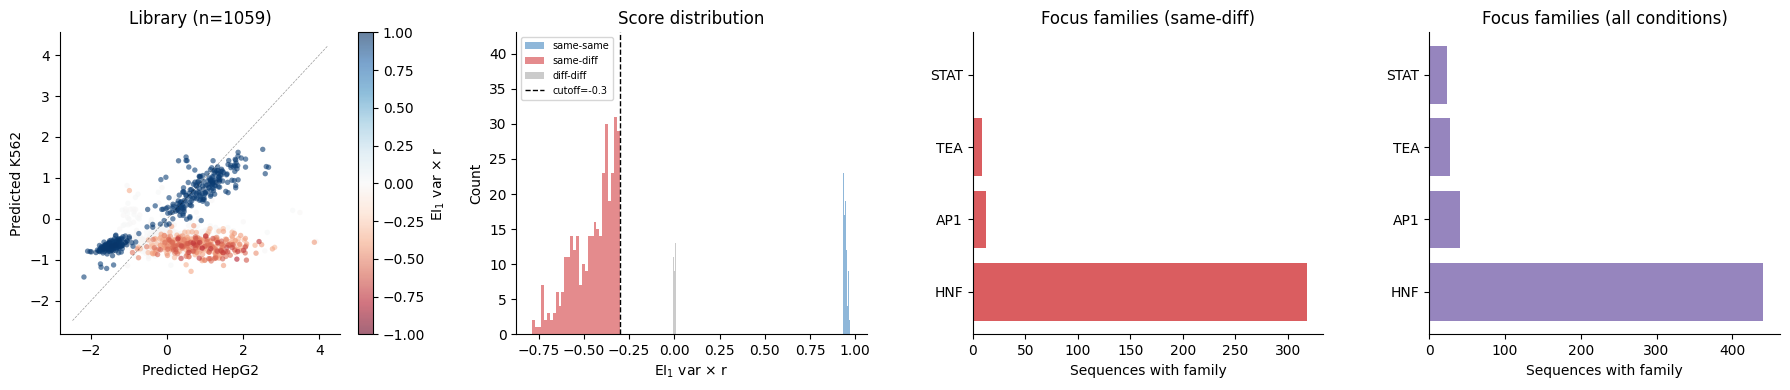

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1) HepG2 vs K562 predictions colored by EI_1 var x r
order = np.argsort(np.abs(df['EI_1 var x r'].values))
sc = axes[0].scatter(df.pred_HepG2.values[order], df.pred_K562.values[order],
                     s=15, alpha=0.6, c=df['EI_1 var x r'].values[order],
                     cmap='RdBu', vmin=-1, vmax=1, edgecolors='none')
lims = [df[['pred_HepG2','pred_K562']].min().min()-0.3, df[['pred_HepG2','pred_K562']].max().max()+0.3]
axes[0].plot(lims, lims, 'k--', lw=0.5, alpha=0.4)
axes[0].set_xlabel('Predicted HepG2'); axes[0].set_ylabel('Predicted K562')
plt.colorbar(sc, ax=axes[0], label='EI$_1$ var $\\times$ r')
axes[0].set_title(f'Library (n={len(df)})')

# 2) EI_1 var x r distribution by condition
cmap_d = {'same-same': '#2171b5', 'same-diff': '#cb181d', 'diff-diff': '#999999'}
for cond in ['same-same', 'same-diff', 'diff-diff']:
    vals = df.loc[df.condition == cond, 'EI_1 var x r']
    axes[1].hist(vals, bins=30, alpha=0.5, color=cmap_d[cond], label=cond)
axes[1].axvline(lib['ei_cutoff'], color='k', ls='--', lw=1, label=f'cutoff={lib["ei_cutoff"]}')
axes[1].set_xlabel('EI$_1$ var $\\times$ r'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=7); axes[1].set_title('Score distribution')

# 3) Focus family counts in same-diff
fam_counts = Counter()
for fams in sd_focus.families:
    fam_counts.update(fams)
fams_sorted = sorted(fam_counts, key=fam_counts.get, reverse=True)
axes[2].barh(fams_sorted, [fam_counts[f] for f in fams_sorted], color='#cb181d', alpha=0.7)
axes[2].set_xlabel('Sequences with family'); axes[2].set_title('Focus families (same-diff)')

# 4) Focus family counts across entire library
fam_counts_all = Counter()
for _, row in df.iterrows():
    seq_tfs = set(row.all_tfs.split(','))
    for fam, members in focus_families.items():
        if seq_tfs & set(members):
            fam_counts_all[fam] += 1
fams_sorted_all = sorted(fam_counts_all, key=fam_counts_all.get, reverse=True)
axes[3].barh(fams_sorted_all, [fam_counts_all[f] for f in fams_sorted_all], color='#6a51a3', alpha=0.7)
axes[3].set_xlabel('Sequences with family'); axes[3].set_title('Focus families (all conditions)')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

same-diff | seq_idx=56772  EI1_vxr=-0.785
  pred_HepG2=1.84  pred_K562=-0.98
  TFs: BCL6B,HMBOX1,HNF1A,HNF1B,POU6F1,SOX10,ZNF286B


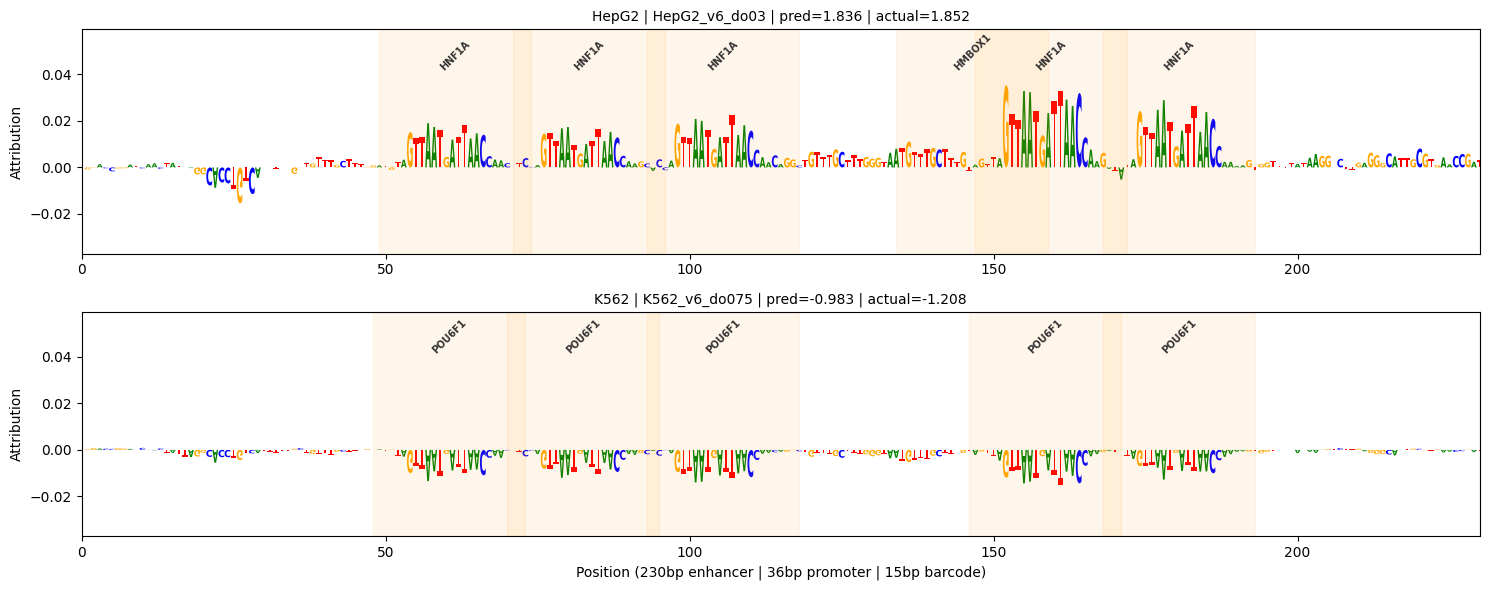

In [7]:
## same-diff: most negative EI_1 var x r

idx = df[df.condition == 'same-diff']['EI_1 var x r'].idxmin()
row = df.loc[idx]
local_idx = df.index.get_loc(idx)

print(f'same-diff | seq_idx={row.seq_idx}  EI1_vxr={row["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={row.pred_HepG2:.2f}  pred_K562={row.pred_K562:.2f}')
print(f'  TFs: {row.all_tfs}')

em.plot_attr_logos_with_motifs(seq_idx=local_idx, figsize=FIGSIZE_ROW)
for ax in plt.gcf().axes: ax.set_xlim(0, 230)

plt.savefig('../results/HNF1A-POU6F1.png', dpi=300, bbox_inches='tight')

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 5 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 10/10 TF assignments changed across 1 sequences (sigma=0.642)


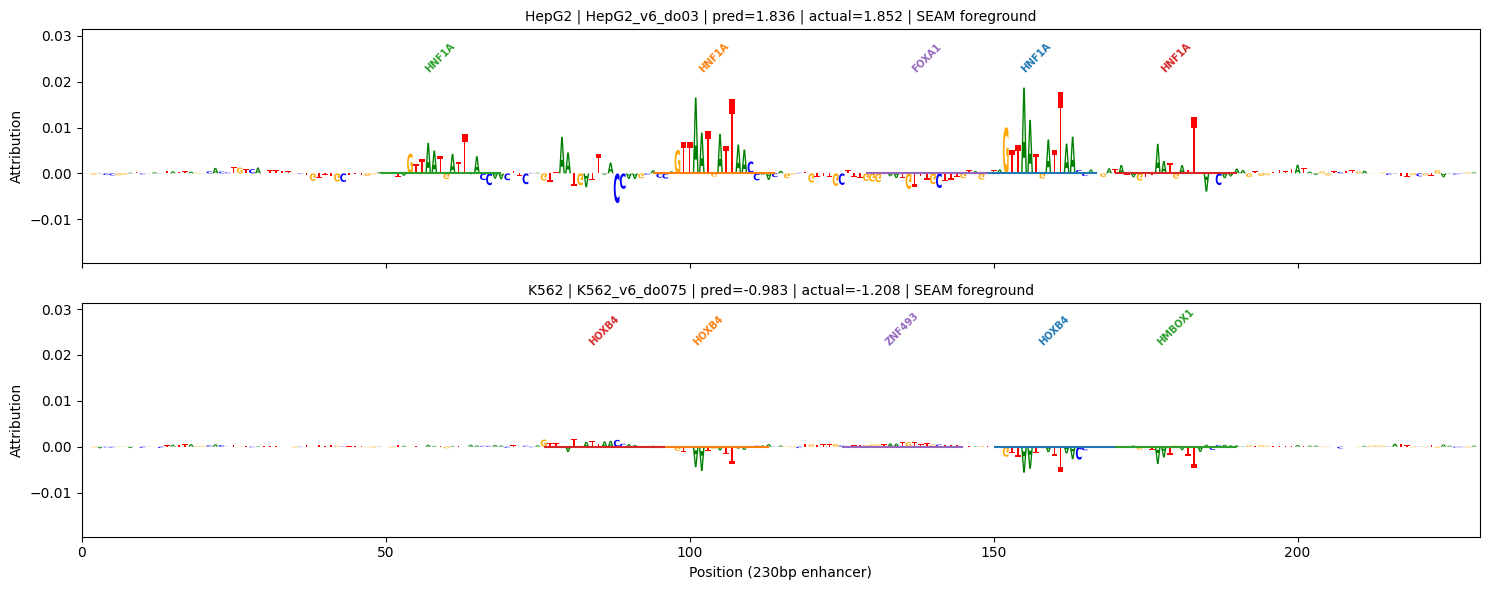

In [8]:
show_fg(row)

same-same | seq_idx=53997  EI1_vxr=0.977
  pred_HepG2=-1.26  pred_K562=-0.53
  TFs: Hoxd13,MAFF,NRL,Nr2F6,REST,Rarb,ZNF410,ZNF449,ZNF493


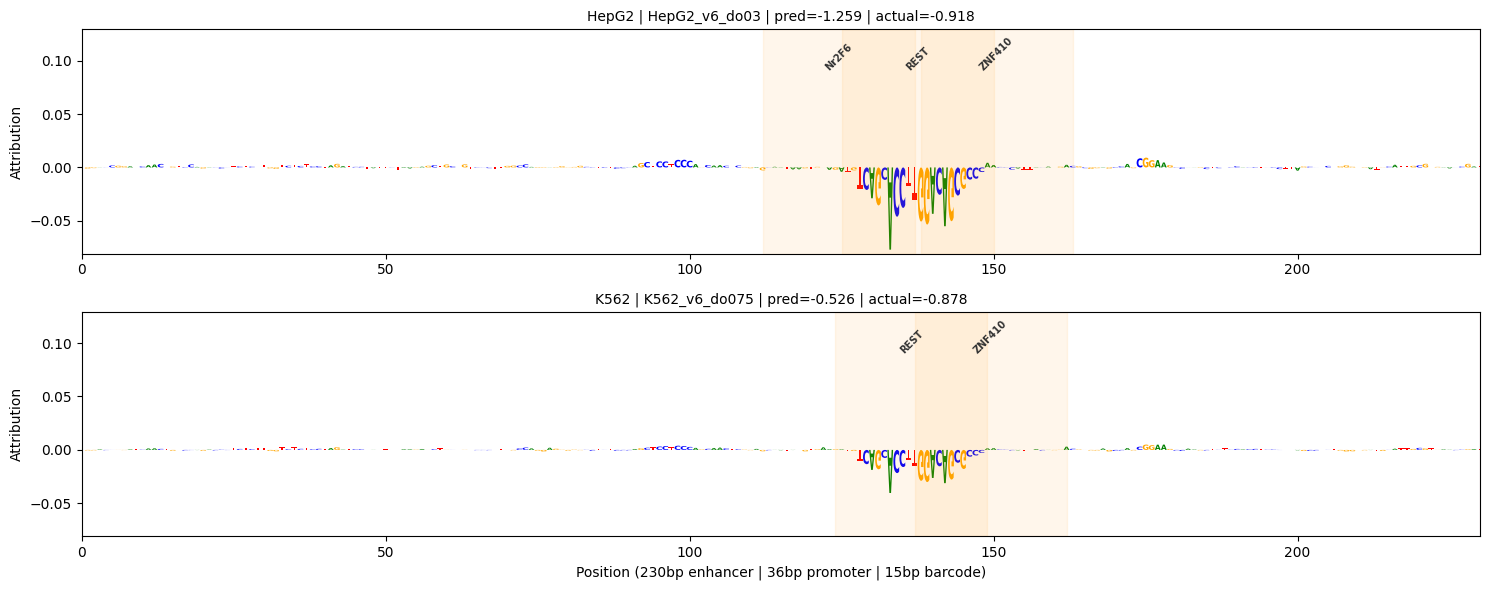

In [9]:
## same-same: most positive EI_1 var x r

idx = df[df.condition == 'same-same']['EI_1 var x r'].idxmax()
row = df.loc[idx]
local_idx = df.index.get_loc(idx)

print(f'same-same | seq_idx={row.seq_idx}  EI1_vxr={row["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={row.pred_HepG2:.2f}  pred_K562={row.pred_K562:.2f}')
print(f'  TFs: {row.all_tfs}')

em.plot_attr_logos_with_motifs(seq_idx=local_idx, figsize=FIGSIZE_ROW)
for ax in plt.gcf().axes: ax.set_xlim(0, 230)

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])


  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 6 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 7/11 TF assignments changed across 1 sequences (sigma=0.642)


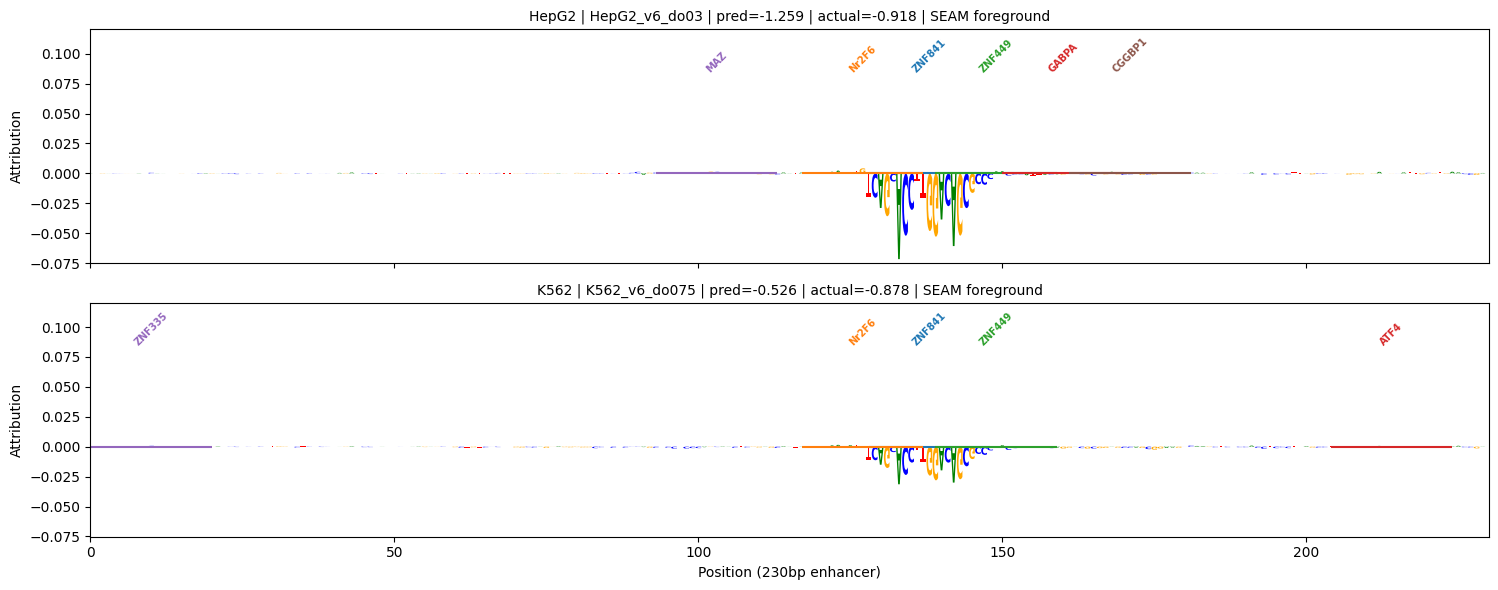

In [10]:
show_fg(row)

diff-diff | seq_idx=26012  EI1_vxr=-0.000
  pred_HepG2=-0.96  pred_K562=0.24
  TFs: GATA2,GATA4,GATA6,TRPS1


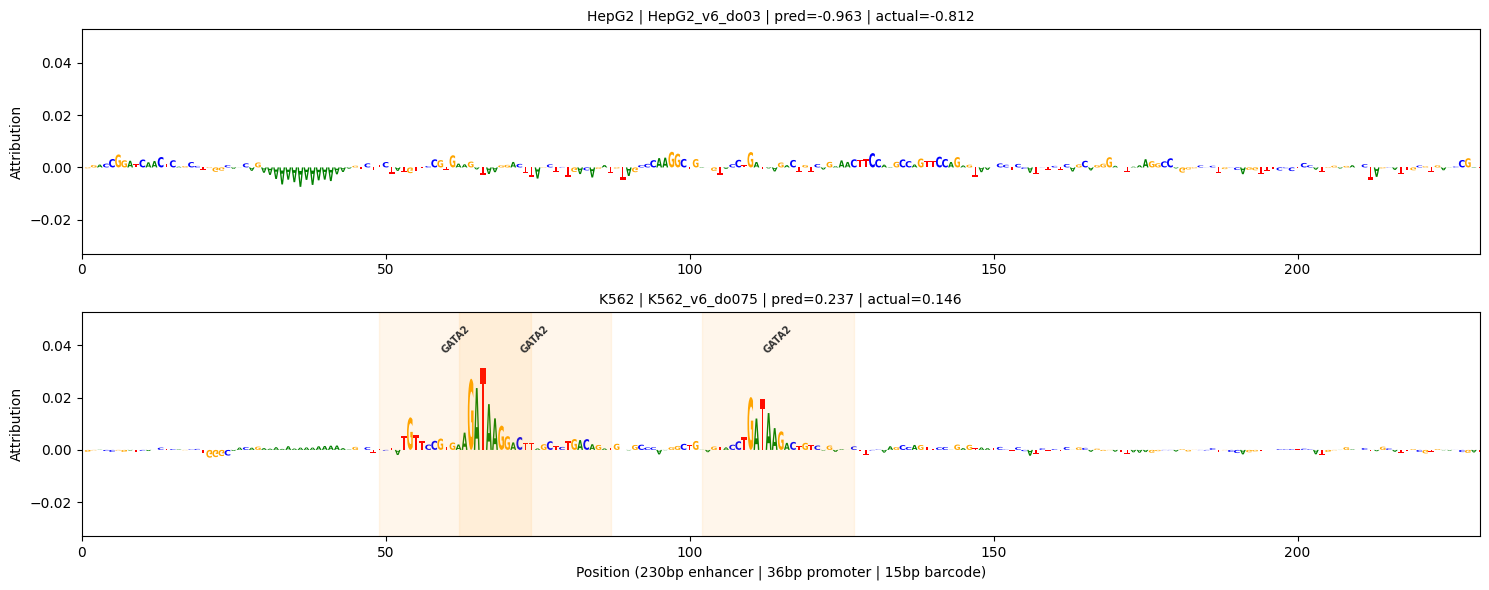

In [11]:
## diff-diff: random seq near EI_1 var x r ~ 0

dd = df[df.condition == 'diff-diff']
near_zero = dd.iloc[(dd['EI_1 var x r'].abs()).argsort().values[0]]
idx = near_zero.name
local_idx = df.index.get_loc(idx)

print(f'diff-diff | seq_idx={near_zero.seq_idx}  EI1_vxr={near_zero["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={near_zero.pred_HepG2:.2f}  pred_K562={near_zero.pred_K562:.2f}')
print(f'  TFs: {near_zero.all_tfs}')

em.plot_attr_logos_with_motifs(seq_idx=local_idx, figsize=FIGSIZE_ROW)
for ax in plt.gcf().axes: ax.set_xlim(0, 230)

EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 6 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 8/11 TF assignments changed across 1 sequences (sigma=0.642)


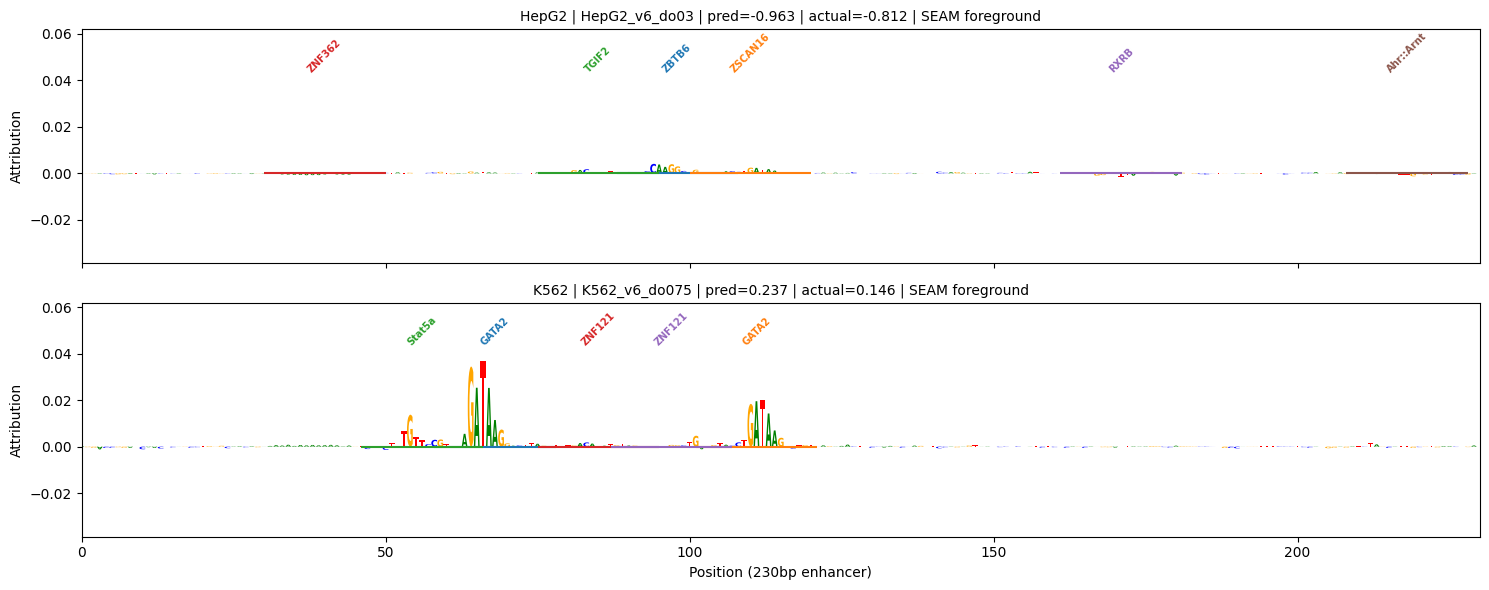

In [12]:
show_fg(near_zero)

same-diff | seq_idx=56772  EI1_vxr=-0.785
  pred_HepG2=1.84  pred_K562=-0.98


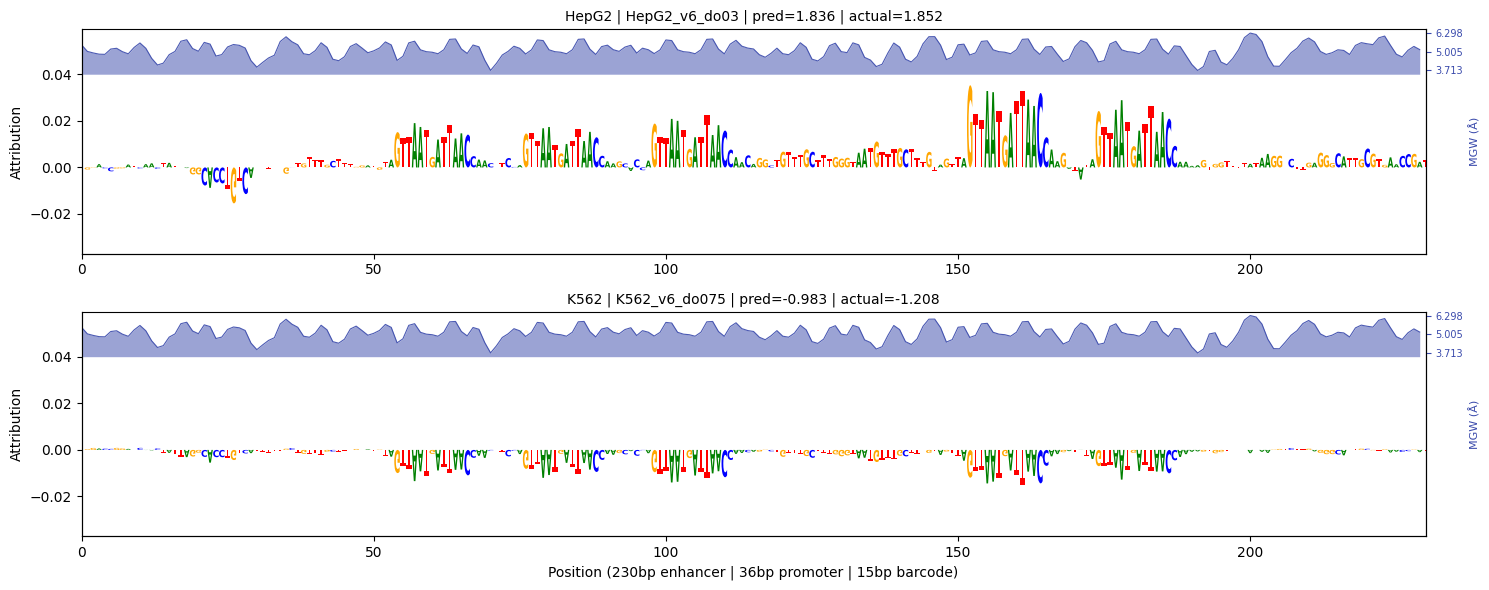

In [13]:
## test deep_dnashape — same-diff most negative, MGW over full 230bp enhancer

idx = df[df.condition == 'same-diff']['EI_1 var x r'].idxmin()
row = df.loc[idx]
local_idx = df.index.get_loc(idx)

print(f'same-diff | seq_idx={row.seq_idx}  EI1_vxr={row["EI_1 var x r"]:.3f}')
print(f'  pred_HepG2={row.pred_HepG2:.2f}  pred_K562={row.pred_K562:.2f}')

# Need enhancer strings on em for deep_dnashape; (re)load if missing
if not em.enhancers:
    em.enhancers = [s[:230] for s in df.sequence.values]

# Reset shape cache for this seq so reruns don't stack
if hasattr(em, 'shape_annotations'):
    em.shape_annotations.pop(local_idx, None)

# Single scan over the whole enhancer (comparable bar heights across positions)
em.deep_dnashape(local_idx, 0, 230, feature='MGW')

em.plot_attr_logos_with_motifs(seq_idx=local_idx, figsize=FIGSIZE_ROW,
                                motif_annotations=False, shape_annotations=True)
for ax in plt.gcf().axes: ax.set_xlim(0, 230)



EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_twostep_v4_do03', 'K562': 'K562_twostep_v4_do03'}
Loaded 1 sequences, X shape: torch.Size([1, 4, 281])
  HepG2: 58721 genes, median TPM=0.00
  K562: 58721 genes, median TPM=0.00
  TF lookup: 57133 gene symbols across ['HepG2', 'K562']
  HepG2: 5 motif hits (p<0.05)
  K562: 5 motif hits (p<0.05)
Eigendecomposed 1 sequences (enhancer only, 230bp)
annotate_tf_binding(gaussian): 10/10 TF assignments changed across 1 sequences (sigma=0.642)


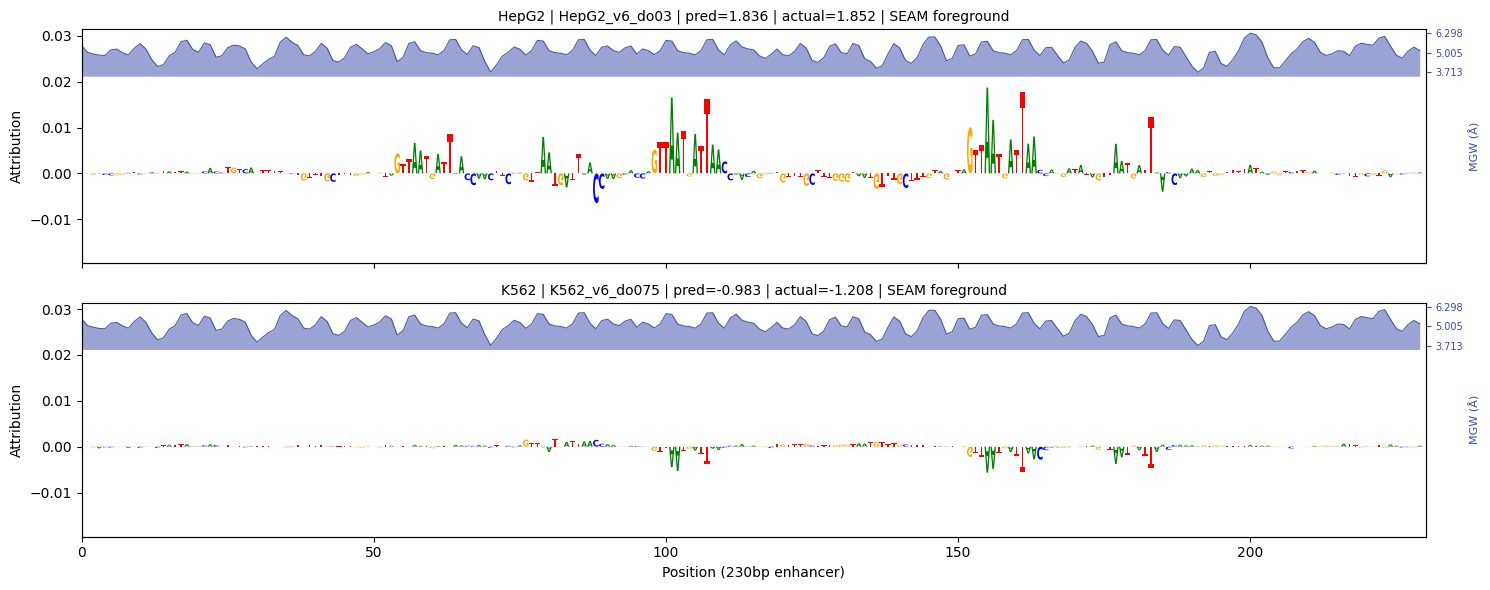

In [14]:
## foreground of same row with MGW overlay
show_fg(row, motif_annotations=False, shape_feature='MGW')
